In [60]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import ticker

from protein_search_evals.datasets.pfam import Pfam20Dataset
from protein_search_evals.evaluate import EvaluationMetadata
from protein_search_evals.evaluate import EvaluatorOutput

# Sequence length distribution

In [62]:
def plot_histogram(
    data: list[float] | list[int],
    xlabel: str,
    ylabel: str,
    title: str = '',
    bins: int | None = None,
    save_path: str | None = None,
    show_stats: bool = False,
    stats_position: tuple[float, float] = (0.02, 0.98),
) -> None:
    """Plot a histogram with automatically computed number of bins.

    Parameters
    ----------
    data : list[float] | list[int]
        Data to plot in the histogram.
    xlabel : str
        Label for the x-axis.
    ylabel : str
        Label for the y-axis.
    title : str, optional
        Title of the plot, by default "" (no title).
    bins : int | None, optional
        The number of bins to use.
    save_path : str | None, optional
        If provided, saves the figure to the given path, by default None.
    show_stats : bool, optional
        If True, displays a text box with statistical information, by default False.
    stats_position : tuple[float, float], optional
        Position of the statistics text box in axes coordinates (x, y),
        by default (0.02, 0.98) (top-left corner).

    Returns
    -------
    None
    """
    # High-quality publication settings
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update(
        {
            'font.family': 'serif',
            'font.size': 14,
            'axes.titlesize': 16,
            'axes.labelsize': 14,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'figure.dpi': 300,
        },
    )

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the histogram
    ax.hist(data, bins=bins, color='steelblue', edgecolor='black', alpha=0.7)

    # Customize the plot
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if title:
        ax.set_title(title)
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

    # Add statistics text box if requested
    if show_stats:
        # Calculate statistics
        mean_val = np.mean(data)
        median_val = np.median(data)
        min_val = np.min(data)
        max_val = np.max(data)
        std_val = np.std(data)

        # Create statistics text
        stats_text = (
            f'Mean: {mean_val:.2f}\n'
            f'Median: {median_val:.2f}\n'
            f'Std: {std_val:.2f}\n'
            f'Min: {min_val:.2f}\n'
            f'Max: {max_val:.2f}'
        )

        # Add text box with statistics
        ax.text(
            stats_position[0],
            stats_position[1],
            stats_text,
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            horizontalalignment='left',
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='white',
                alpha=0.8,
                edgecolor='gray',
            ),
        )

    # Optimize layout
    plt.tight_layout()

    # Save if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')

    # Show the plot
    plt.show()

In [63]:
data_dir = '../../data/pfam'
sequences = Pfam20Dataset(data_dir).load_sequences()

Loading Pfam20 families metadata from ../../data/pfam/pfam20_seed-42/sequences.fasta


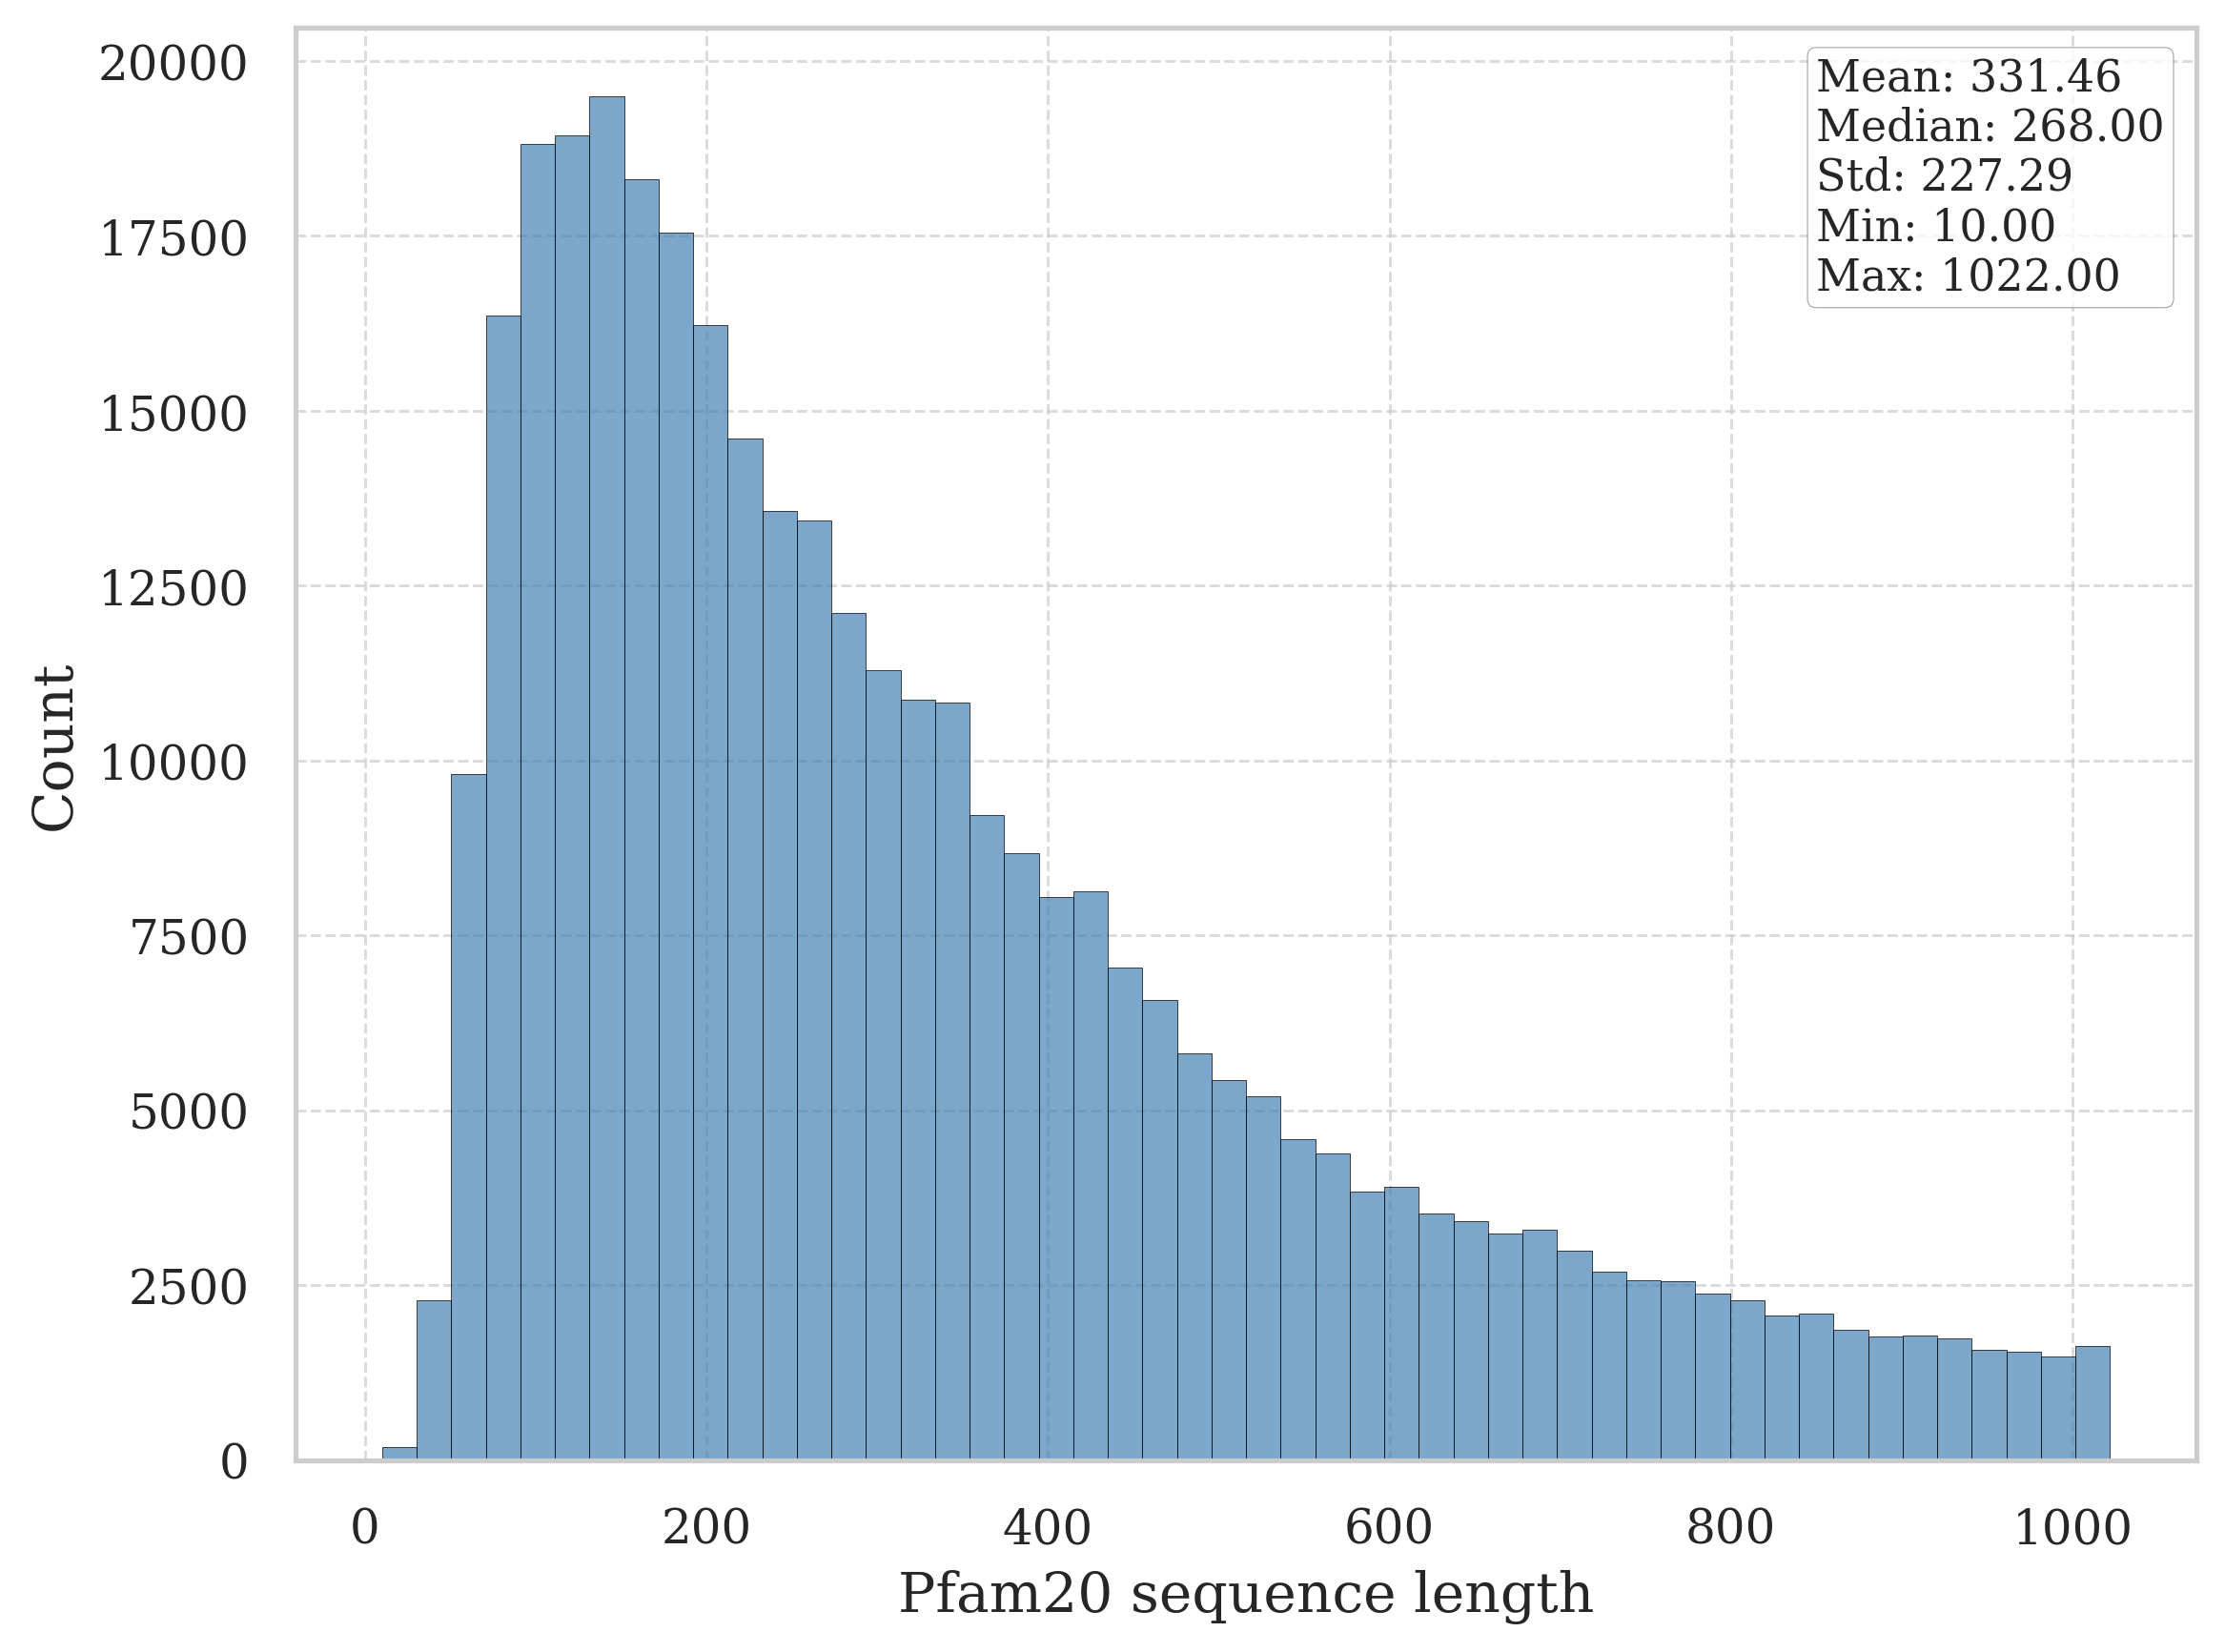

Mean sequence length: 331.45836695266775
Median sequence length: 268.0
Std sequence length: 227.29441733855637
Max sequence length: 1022
Min sequence length: 10


In [ ]:
# Plot the sequence lengths
lengths = [len(x.sequence) for x in sequences]

plot_histogram(
    data=lengths,
    xlabel='Pfam20 sequence length',
    ylabel='Count',
    bins=50,
    # save_path='evaluations/figures/pfam_sequence_lengths.pdf',
    save_path='evaluations/figures/png/pfam_sequence_lengths.png',
    show_stats=True,  # Enable statistics text box
    stats_position=(0.8, 0.98),  # Position in top-right corner
)

# Print the summary statistics
print(f'Mean sequence length: {np.mean(lengths)}')
print(f'Median sequence length: {np.median(lengths)}')
print(f'Std sequence length: {np.std(lengths)}')
print(f'Max sequence length: {np.max(lengths)}')
print(f'Min sequence length: {np.min(lengths)}')

# Accuracy evaluation

In [67]:
def get_metadata(
    model_names: list[str],
    precision: str,
    partition: str,
) -> list[EvaluationMetadata]:
    """Load the evaluation metadata for a list of model names.

    Parameters
    ----------
    model_names : list[str]
        List of model names.
    precision : str
        Precision of the model.
    partition : str
        Partition of the dataset.

    Returns
    -------
    list[EvaluationMetadata]
        List of evaluation metadata objects.
    """
    # The root path for the evaluation metadata of the given partition
    path = Path('evaluations/reports') / partition

    # Construct the paths for the evaluation metadata
    eval_paths = [
        path / f'report_{model_name}_{precision}_{partition}_metadata.json'
        for model_name in model_names
    ]

    # Load the evaluation metadata
    return [EvaluationMetadata.from_json(x) for x in eval_paths]


def get_accuracies(
    metadata: list[EvaluationMetadata],
    metric: str,
) -> list[float]:
    """Get the accuracies from a list of evaluation metadata objects.

    Parameters
    ----------
    metadata : list[EvaluationMetadata]
        List of evaluation metadata objects.
    metric : str
        Metric to extract the accuracies from.

    Returns
    -------
    list[float]
        List of accuracies.
    """
    if metric == 'sequence_level_mean_accuracy':
        return [x.sequence_level_mean_accuracy for x in metadata]
    elif metric == 'cluster_level_mean_accuracy':
        return [x.cluster_level_mean_accuracy for x in metadata]
    elif metric == 'cluster_level_median_accuracy':
        return [x.cluster_level_median_accuracy for x in metadata]
    else:
        raise ValueError(f'Invalid metric: {metric}')


# Model names for the ESM-2 models
esm2_model_names = [
    'esm2_t6_8M_UR50D',
    'esm2_t12_35M_UR50D',
    'esm2_t30_150M_UR50D',
    'esm2_t33_650M_UR50D',
    'esm2_t36_3B_UR50D',
    'esm2_t48_15B_UR50D',
]

# Model names for the ESM-C models
esmc_model_names = [
    'esmc_300m',
    'esmc_600m',
]

# Model name for ProtTrans
prottrans_model_names = [
    'prot_t5_xl_half_uniref50-enc',
]

In [68]:
def plot_accuracy_vs_model_size(
    data: dict[str, list[list[int] | list[float] | list[str]]],
    ylabel: str = '',
    annotation_offset: float = 0.005,
    save_path: str | None = None,
) -> None:
    """Plot accuracy scaling with model size.

    Parameters
    ----------
    data : dict[str, list[int] | list[float] | list[str]]
        Dictionary of model names to sizes, accuracies, and labels.
    ylabel: str
        Y-label of the plot.
    annotation_offset: float
        Offset for the annotation text.
    save_path : str | None, optional
        If provided, saves the figure to the given path, by default None.
    """
    # Plot settings
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(8, 6))

    for key, values in data.items():
        sizes, accuracies, labels = values
        # Scatter plot
        scatter = sns.scatterplot(
            x=sizes,
            y=accuracies,
            s=100,
            edgecolor='black',
            label=key,
        )

        # Get color from the last scatter point
        color = scatter.collections[-1].get_facecolor()[
            0
        ]  # Extract RGBA color

        # Line plot (connecting points)
        plt.plot(
            sizes,
            accuracies,
            linestyle='-',
            marker='',
            color=color,
            alpha=0.7,
        )

        # Annotate points
        for size, acc, label in zip(sizes, accuracies, labels):
            plt.text(
                size,
                acc + annotation_offset,
                label,
                fontsize=9,
                ha='center',
                va='bottom',
            )

    # Limit the number of y-ticks to a maximum of 7
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=7))

    # Format y-axis labels to two decimal places
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    # Ensure 99% is included in y-axis ticks
    y_ticks = plt.yticks()[0]  # Get current y-ticks
    if 0.99 not in [round(x, 2) for x in y_ticks]:
        y_ticks = np.append(y_ticks, 0.99)  # Add 99% if not present
        y_ticks = np.sort(y_ticks)  # Ensure sorted order
    plt.yticks(y_ticks)  # Apply updated ticks

    # Limit the y-axis range to [0, 1.0]
    plt.ylim(np.min(y_ticks), 1.0)

    # Log scale for model size
    plt.xscale('log')

    # Labels and title
    plt.xlabel('Model Scale (Parameters)', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    # Set the legend location
    plt.legend(loc='lower right')
    # plt.legend(loc='upper left')

    # Adjust grid line appearance (lighter)
    plt.grid(True, linewidth=0.5, alpha=0.4)

    # Save the plot as a high-resolution PDF
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300)

    plt.show()

In [69]:
esm2_plot_names = [
    'ESM2 8M',
    'ESM2 35M',
    'ESM2 150M',
    'ESM2 650M',
    'ESM2 3B',
    'ESM2 15B',
]

esm2_plot_sizes = [
    8 * 10**6,
    35 * 10**6,
    150 * 10**6,
    650 * 10**6,
    3000 * 10**6,
    15 * 10**9,
]

esmc_plot_names = [
    'ESMC 300M',
    'ESMC 600M',
]

esmc_plot_sizes = [
    300 * 10**6,
    600 * 10**6,
]

prottrans_plot_names = [
    'ProtT5-XL-U50',
]

prottrans_plot_sizes = [
    3000 * 10**6,
]

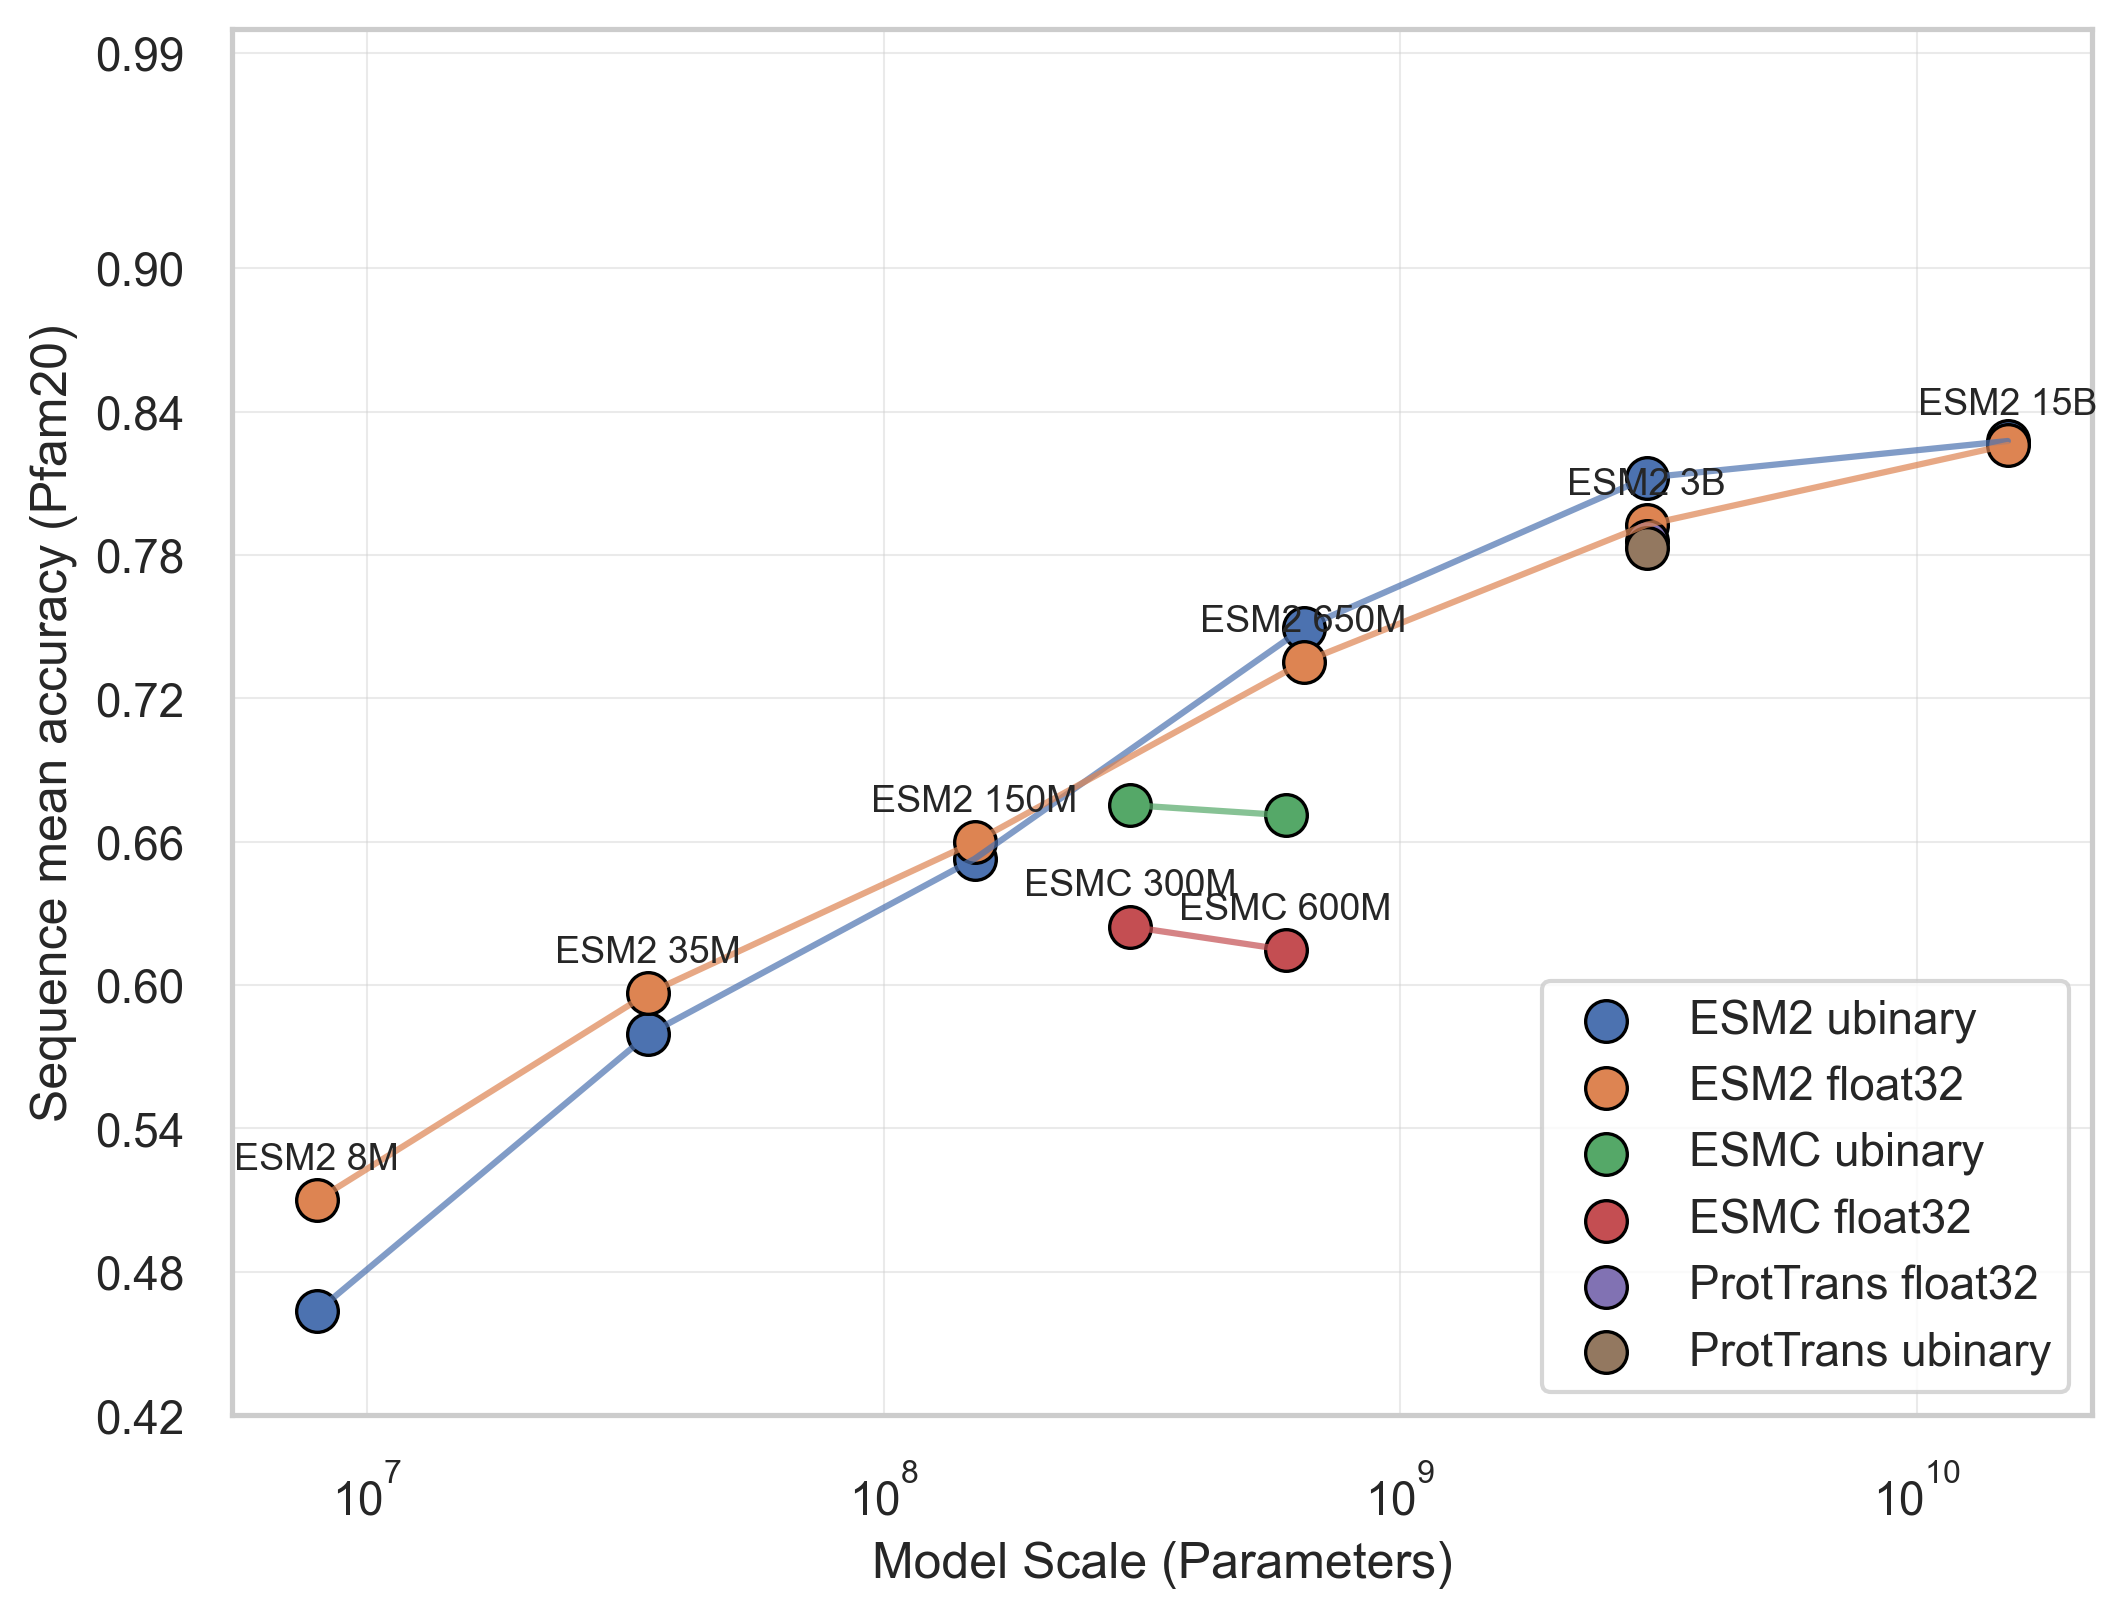

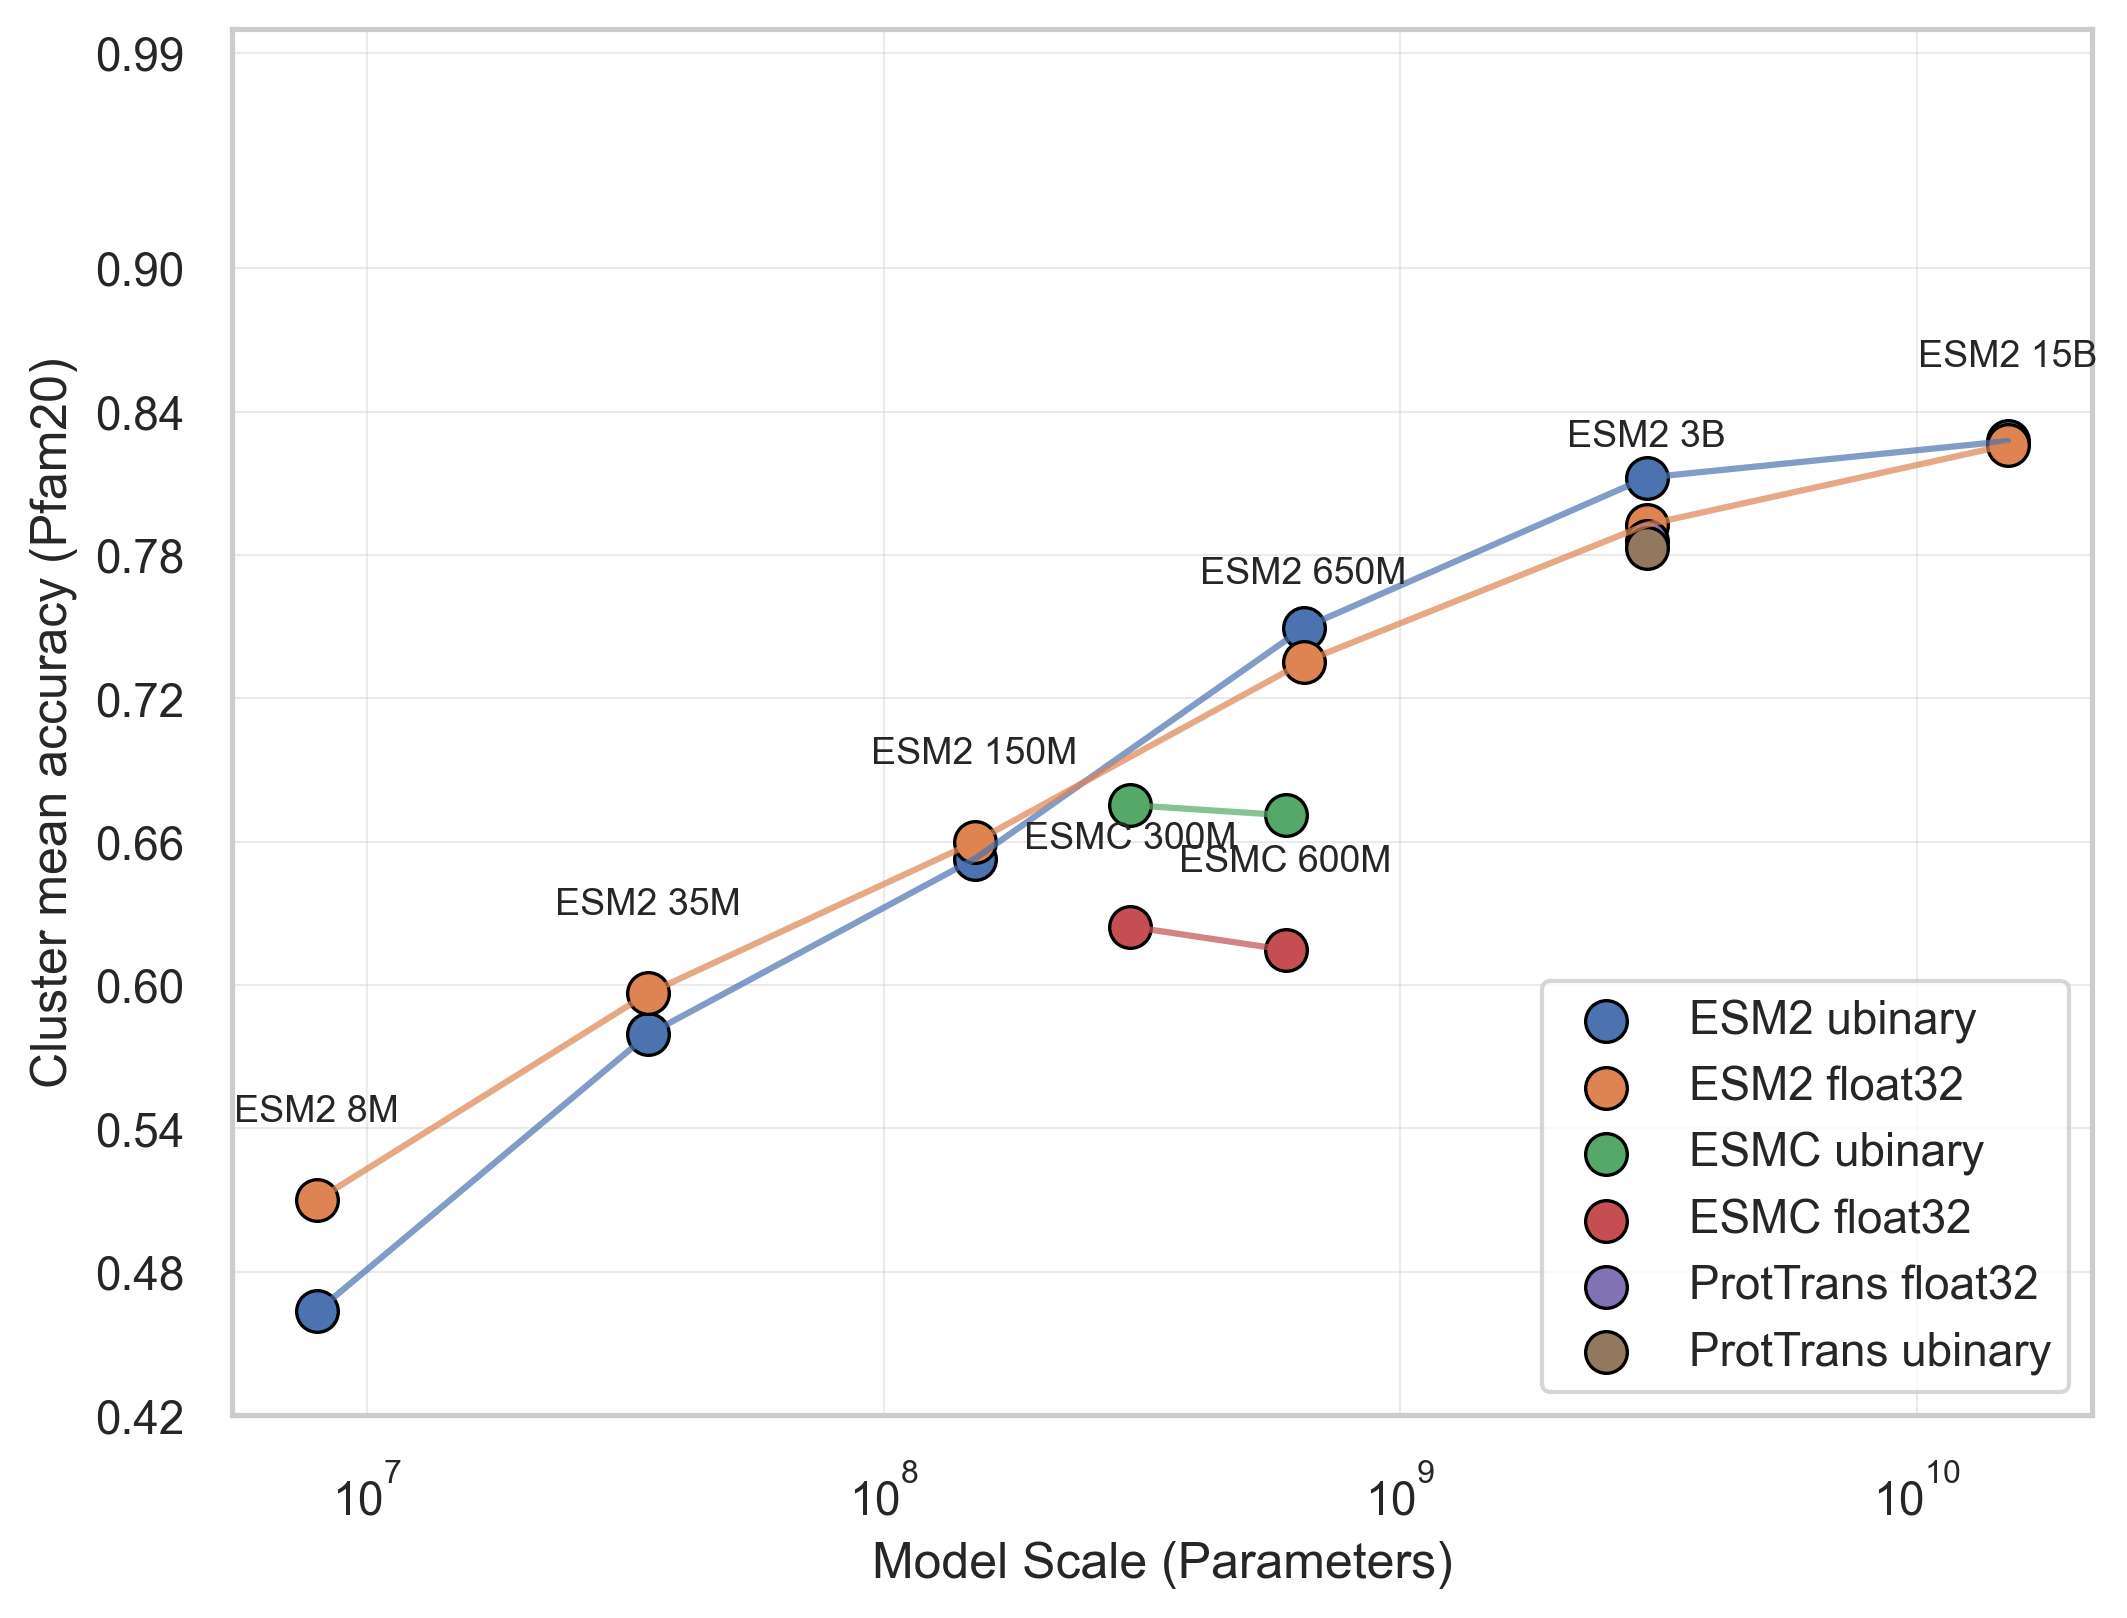

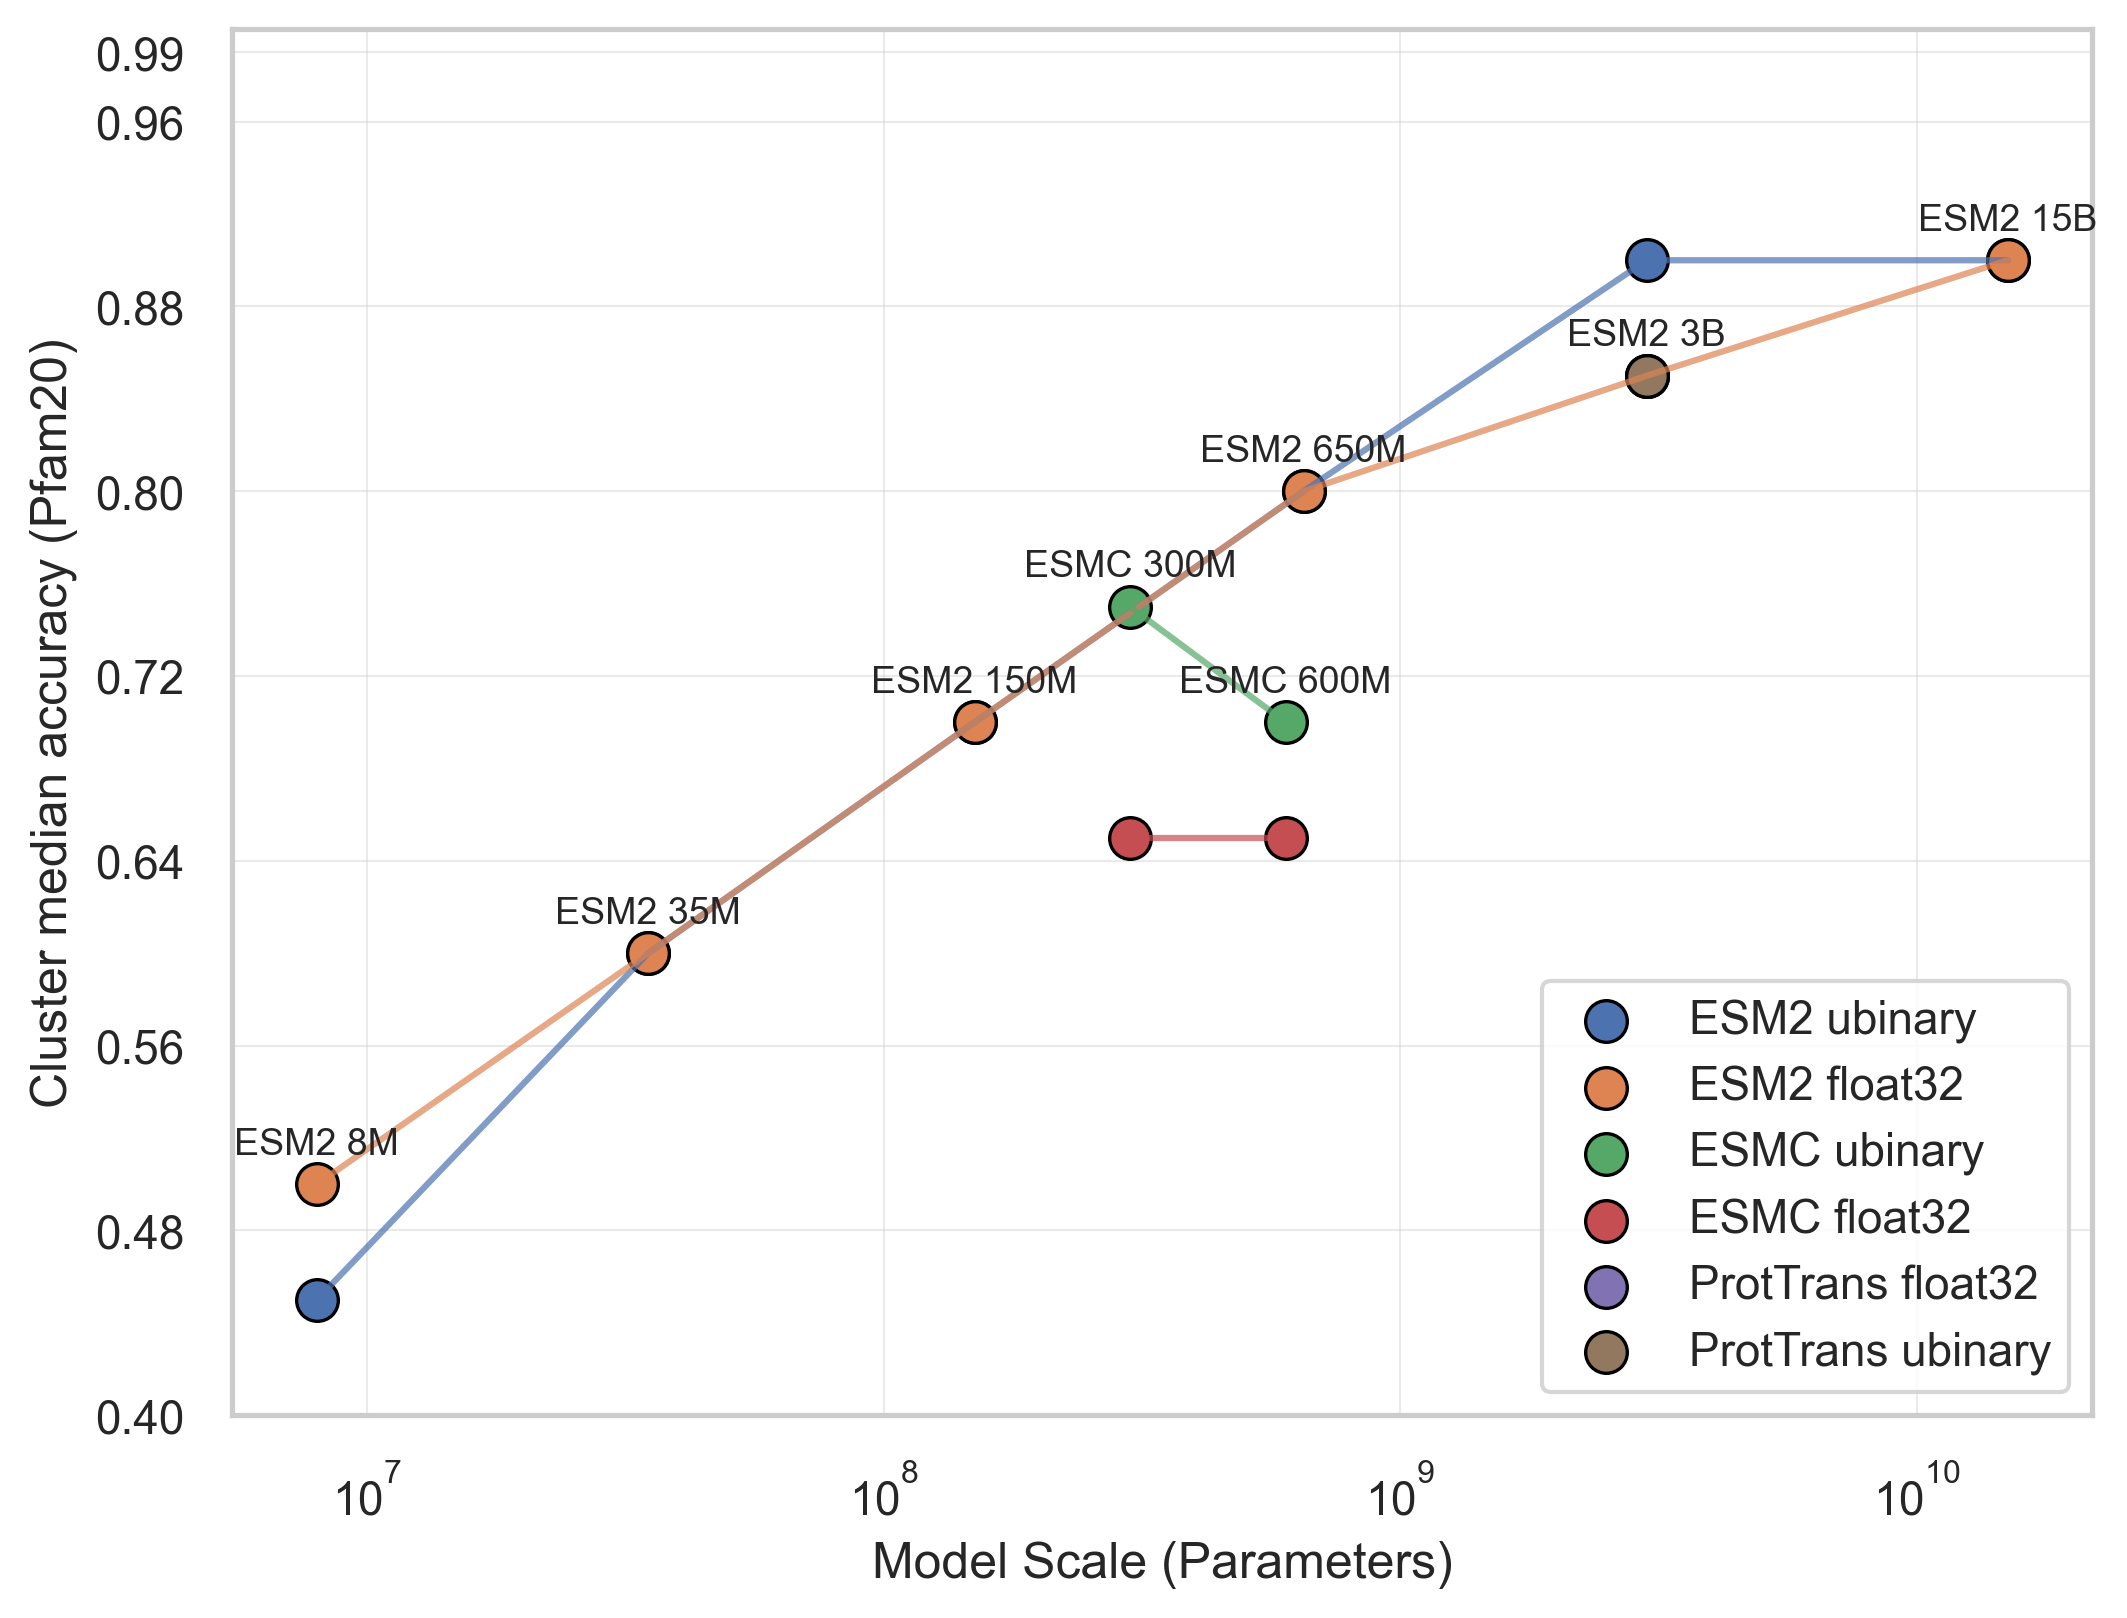

In [74]:
# Load the partition data
partition = 'seed-42'
ylabel_dataname = 'Pfam20'
esm2_float32 = get_metadata(esm2_model_names, 'float32', partition)
esm2_ubinary = get_metadata(esm2_model_names, 'ubinary', partition)
esmc_float32 = get_metadata(esmc_model_names, 'float32', partition)
esmc_ubinary = get_metadata(esmc_model_names, 'ubinary', partition)
prottrans_float32 = get_metadata(prottrans_model_names, 'float32', partition)
prottrans_ubinary = get_metadata(prottrans_model_names, 'ubinary', partition)

metric = 'sequence_level_mean_accuracy'
plot_accuracy_vs_model_size(
    ylabel=f'Sequence mean accuracy ({ylabel_dataname})',
    data={
        'ESM2 ubinary': [
            esm2_plot_sizes,
            get_accuracies(esm2_ubinary, metric),
            [],
        ],
        'ESM2 float32': [
            esm2_plot_sizes,
            get_accuracies(esm2_float32, metric),
            esm2_plot_names,
        ],
        'ESMC ubinary': [
            esmc_plot_sizes,
            get_accuracies(esmc_ubinary, metric),
            [],
        ],
        'ESMC float32': [
            esmc_plot_sizes,
            get_accuracies(esmc_float32, metric),
            esmc_plot_names,
        ],
        'ProtTrans float32': [
            prottrans_plot_sizes,
            get_accuracies(prottrans_float32, metric),
            [],
        ],
        'ProtTrans ubinary': [
            prottrans_plot_sizes,
            get_accuracies(prottrans_ubinary, metric),
            [],
        ],
    },
    annotation_offset=0.01,
    save_path='evaluations/figures/pfam20_sequence_mean_accuracy.pdf',
)

metric = 'cluster_level_mean_accuracy'
plot_accuracy_vs_model_size(
    ylabel=f'Cluster mean accuracy ({ylabel_dataname})',
    data={
        'ESM2 ubinary': [
            esm2_plot_sizes,
            get_accuracies(esm2_ubinary, metric),
            [],
        ],
        'ESM2 float32': [
            esm2_plot_sizes,
            get_accuracies(esm2_float32, metric),
            esm2_plot_names,
        ],
        'ESMC ubinary': [
            esmc_plot_sizes,
            get_accuracies(esmc_ubinary, metric),
            [],
        ],
        'ESMC float32': [
            esmc_plot_sizes,
            get_accuracies(esmc_float32, metric),
            esmc_plot_names,
        ],
        'ProtTrans float32': [
            prottrans_plot_sizes,
            get_accuracies(prottrans_float32, metric),
            [],
        ],
        'ProtTrans ubinary': [
            prottrans_plot_sizes,
            get_accuracies(prottrans_ubinary, metric),
            [],
        ],
    },
    annotation_offset=0.03,
    save_path='evaluations/figures/pfam_cluster_mean_accuracy.pdf',
)

metric = 'cluster_level_median_accuracy'
plot_accuracy_vs_model_size(
    ylabel=f'Cluster median accuracy ({ylabel_dataname})',
    data={
        'ESM2 ubinary': [
            esm2_plot_sizes,
            get_accuracies(esm2_ubinary, metric),
            [],
        ],
        'ESM2 float32': [
            esm2_plot_sizes,
            get_accuracies(esm2_float32, metric),
            esm2_plot_names,
        ],
        'ESMC ubinary': [
            esmc_plot_sizes,
            get_accuracies(esmc_ubinary, metric),
            esmc_plot_names,
        ],
        'ESMC float32': [
            esmc_plot_sizes,
            get_accuracies(esmc_float32, metric),
            [],
        ],
        'ProtTrans float32': [
            prottrans_plot_sizes,
            get_accuracies(prottrans_float32, metric),
            [],
        ],
        'ProtTrans ubinary': [
            prottrans_plot_sizes,
            get_accuracies(prottrans_ubinary, metric),
            [],
        ],
    },
    annotation_offset=0.01,
    save_path='evaluations/figures/pfam_cluster_median_accuracy.pdf',
)

# Plot the accuracy distribution per cluster

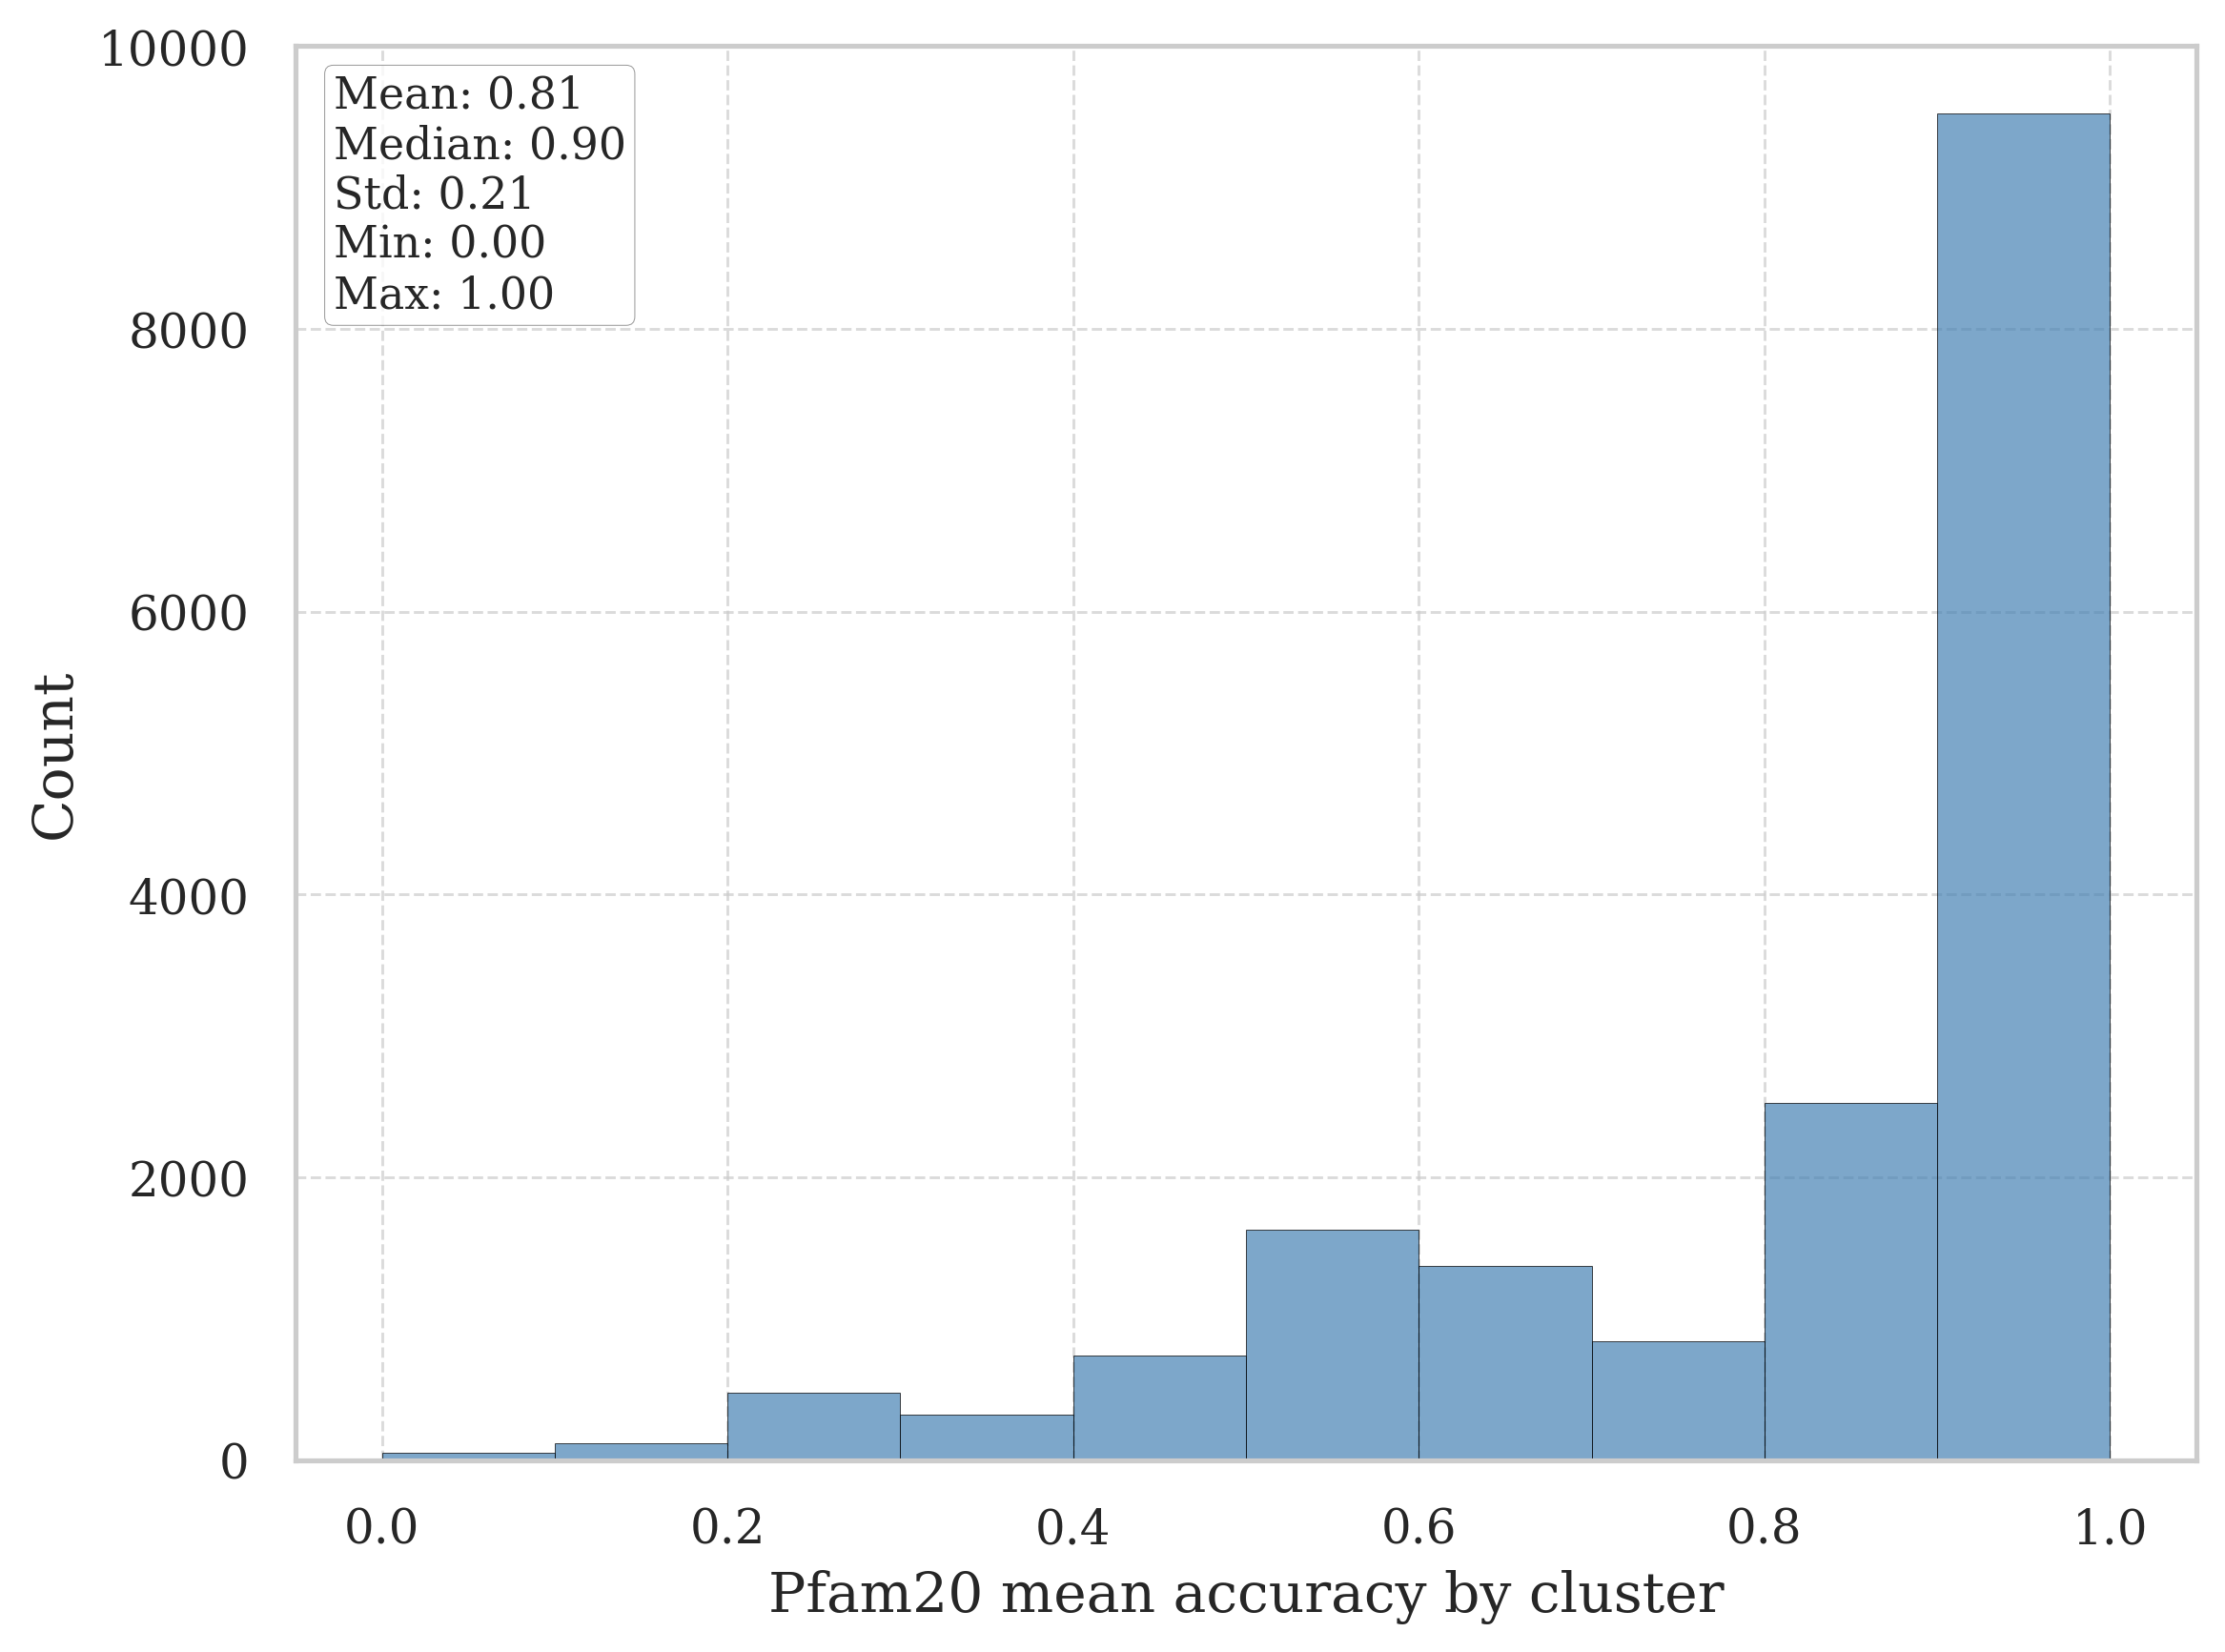

In [ ]:
# Use the ESM2-3B ubinary based search results
path = 'evaluations/reports/seed-42/report_esm2_t36_3B_UR50D_ubinary_seed-42_output.json'
output = EvaluatorOutput.from_json(path)

# Get the list of cluster level mean accuracies
cluster_level_mean_accuracies = list(output.accuracy_by_cluster.values())

# Plot the cluster level mean accuracy histogram
plot_histogram(
    data=cluster_level_mean_accuracies,
    xlabel='Pfam20 mean accuracy by cluster',
    ylabel='Count',
    bins=10,
    save_path='evaluations/figures/pfam_mean_accuracy_by_cluster.pdf',
    # save_path='evaluations/figures/png/pfam_mean_accuracy_by_cluster.png',
    show_stats=True,  # Enable statistics text box
)